# BFSI Credit Risk Analysis
## Business Problem
A leading Indian bank wants to identify which loan applicants are likely to 
repay (P1/P2) versus default (P3/P4) based on tradeline behavior and CIBIL 
profile — to reduce NPA risk and improve credit decisions.#Phase 3 - Exploratory Data Analysis

# Phase 3 — Exploratory Data Analysis
## 3.1 Import Libraries


In [5]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## 3.2 Load Dataset
Loading the merged BFSI dataset into Python for analysis.

In [11]:
df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\Project\Raw data\BFSI merged dataset.xlsx")
print(df.shape)

(51336, 87)


## 3.3 Initial Data Inspection

In [12]:
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,1.820,0,0,AL,AL,753,P1


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 87 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   Total_TL                      51336 non-null  int64  
 2   Tot_Closed_TL                 51336 non-null  int64  
 3   Tot_Active_TL                 51336 non-null  int64  
 4   Total_TL_opened_L6M           51336 non-null  int64  
 5   Tot_TL_closed_L6M             51336 non-null  int64  
 6   pct_tl_open_L6M               51336 non-null  float64
 7   pct_tl_closed_L6M             51336 non-null  float64
 8   pct_active_tl                 51336 non-null  float64
 9   pct_closed_tl                 51336 non-null  float64
 10  Total_TL_opened_L12M          51336 non-null  int64  
 11  Tot_TL_closed_L12M            51336 non-null  int64  
 12  pct_tl_open_L12M              51336 non-null  float64
 13  pct_tl_close

### Observation
All 87 columns have 51,336 non-null values. No missing values found in the merged dataset. Data types are correct — int64 for count-based columns and float64 for ratio/percentage columns.

In [14]:
df.describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,0.823821,0.167874,0.190414,0.065182,0.170492,0.056302,22.029210,0.271116,0.052887,679.859222
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,0.097323,0.373758,0.376218,0.235706,0.350209,0.213506,1110.284497,0.444540,0.223810,20.502764
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,469.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,0.835000,0.000000,0.000000,0.000000,0.000000,0.000000,1.542000,0.000000,0.000000,669.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,0.835000,0.000000,0.000000,0.000000,0.000000,0.000000,1.820000,0.000000,0.000000,680.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,0.835000,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,1.708000,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000


### Observation
Statistical summary of all 81 numeric columns. Key findings:
- Total_TL max = 235 — extreme outlier, one customer has unusually high number of tradelines
- Average active tradelines = 2.08, median = 1 — majority of customers have very few active tradelines
- Percentage columns (pct_) range between 0 and 1 as expected

In [16]:
df.Approved_Flag.value_counts()

Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

### Observation
Target variable Approved_Flag distribution:
- P2 (low risk) = 32,199 — 63% of applicants
- P3 (medium default) = 7,452 — 14.5%
- P4 (high default) = 5,882 — 11.5%
- P1 (best quality) = 5,803 — 11.3%
Dataset is imbalanced. Combined default risk (P3+P4) = 26% of total applicants.
This imbalance must be kept in mind during model building phase.

## 3.4 Target Variable Distribution

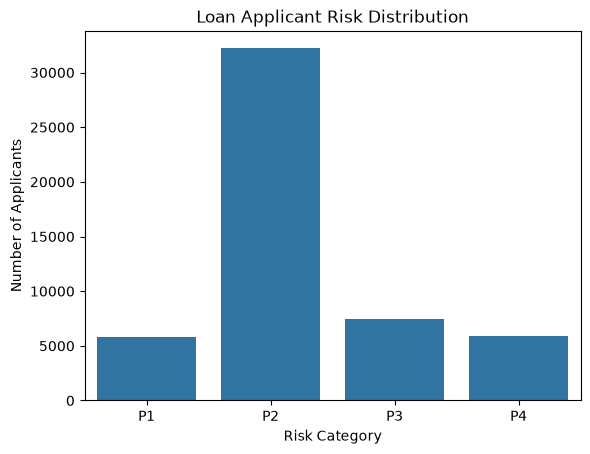

In [17]:
sns.countplot(x='Approved_Flag', data=df, order=['P1','P2','P3','P4'])
plt.title('Loan Applicant Risk Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Number of Applicants')
plt.show(

### Observation
Bar chart confirms class imbalance. P2 (low risk) applicants dominate 
at 63% of total. P1, P3, P4 are significantly smaller in comparison.
This means the bank approves majority of applicants but 1 in 4 still 
carries default risk — which is the core business problem this analysis 
aims to address.

## 3.5 Credit Score Distribution by Risk Category

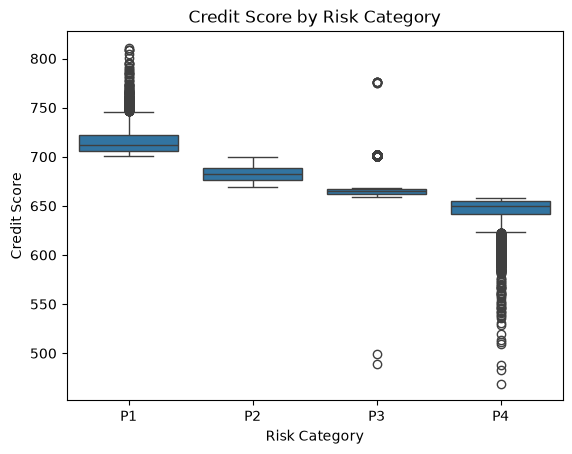

In [18]:
sns.boxplot(x='Approved_Flag', y='Credit_Score', data=df, order=['P1','P2','P3','P4'])
plt.title('Credit Score by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Credit Score')
plt.show()

### Observation
Credit score shows a clear decreasing trend from P1 to P4.
P1 applicants have the highest median credit score (~715).
P4 applicants have the lowest median (~650) with many outliers 
below 500 — indicating seriously distressed borrowers.
This confirms credit score is a strong indicator of repayment behaviour.

## 3.6 Missed Payments by Risk Category

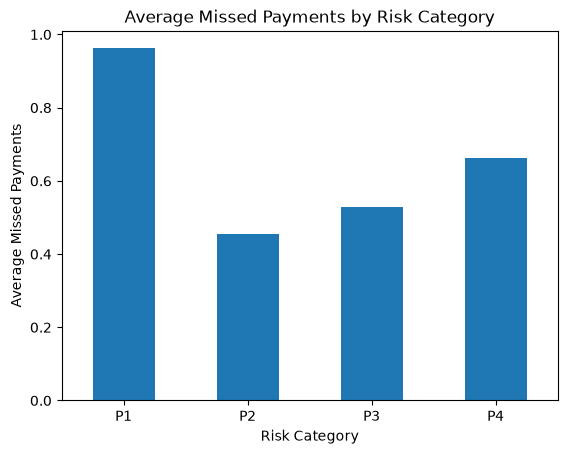

In [20]:
df.groupby('Approved_Flag')['Tot_Missed_Pmnt'].mean().reindex(['P1','P2','P3','P4']).plot(kind='bar')
plt.title('Average Missed Payments by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Average Missed Payments')
plt.xticks(rotation=0)
plt.show()

### Observation
Contrary to expectation, P1 applicants show the highest average missed 
payments. This suggests Tot_Missed_Pmnt alone is not a reliable 
separator between good and bad customers in this dataset. 
Risk classification depends on a combination of factors, not a single column.

## 3.7 Education Level Distribution by Risk Category

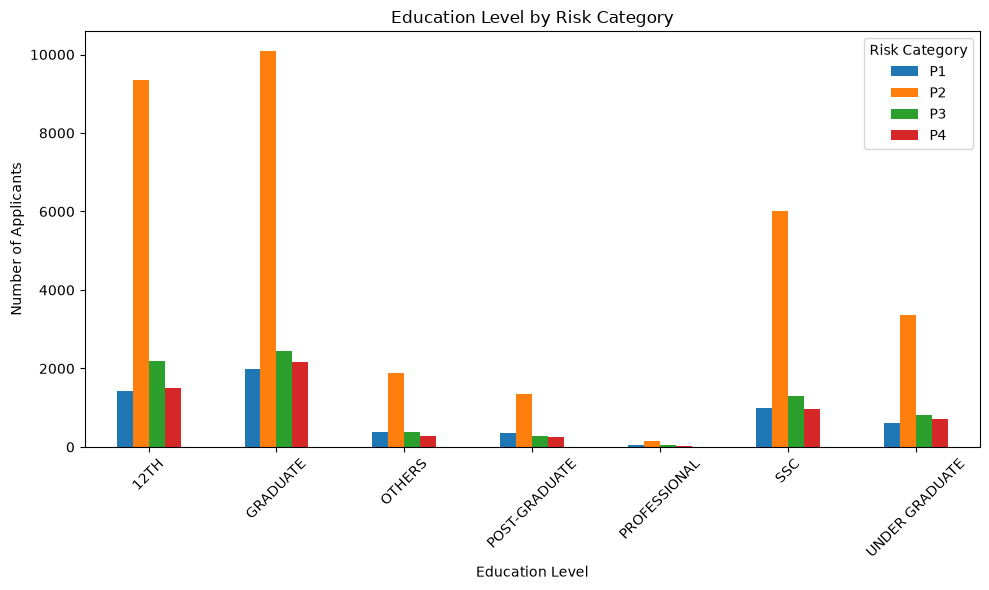

In [21]:
edu_flag = df.groupby(['EDUCATION', 'Approved_Flag']).size().unstack()
edu_flag.plot(kind='bar', figsize=(10,6))
plt.title('Education Level by Risk Category')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()

### Observation
Graduate and 12th pass applicants form the largest groups in this dataset.
Default risk (P3+P4) is present across all education levels, indicating 
that education level alone is not a strong predictor of credit risk.
P2 dominates every category due to overall class imbalance.

## 3.8 Credit Score Distribution

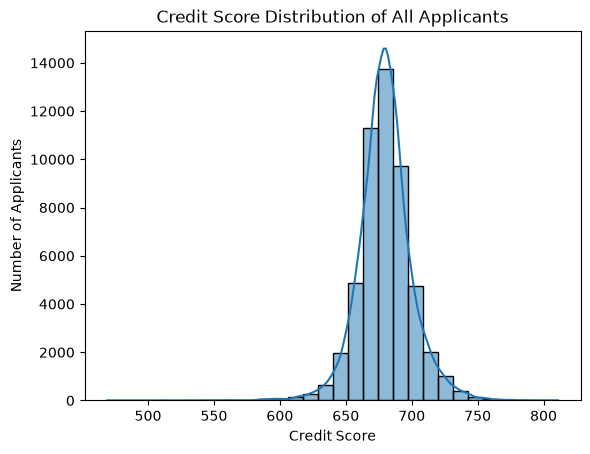

In [22]:
sns.histplot(df['Credit_Score'], bins=30, kde=True)
plt.title('Credit Score Distribution of All Applicants')
plt.xlabel('Credit Score')
plt.ylabel('Number of Applicants')
plt.show()

### Observation
Credit scores follow a normal distribution with majority of applicants 
scoring between 650 and 700. Very few applicants fall below 550 or 
above 750. This suggests the bank is already screening out extreme 
low-score applicants before this stage, and the real differentiation 
between good and bad customers happens within a narrow credit score band.